**8.21.2024 This file is for computing the indicators (inflow&precipitation non bayesian indicators)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
from utils_indicators import *
import utils_GPR as ut
from plot_optimization import *

In [3]:
new_directory = "/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization"
os.chdir(new_directory)
print(os.getcwd())

/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization


In [ ]:
# compute precipitation indicators for normDPS: 20-year moving average and std  of precipitation

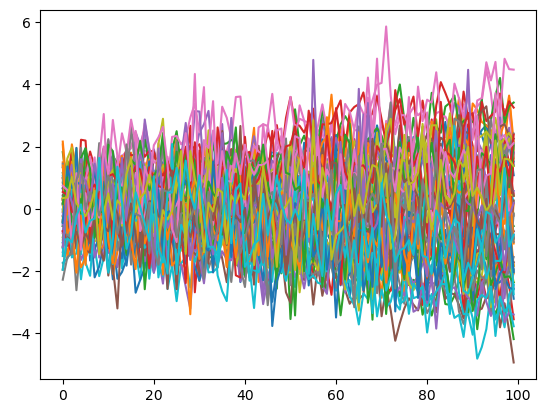

In [8]:
# read in test_month_prep
climate_label = 'test'
month_prep = pd.read_csv('data/Annual_GPR/' + climate_label + '_month_prep.csv')
#compute annual mean precipitation
annual_mean = month_prep.groupby(month_prep.index//12).mean()
annual_mean

# take log and standardize
annual_mean = np.log(annual_mean)
hist_std = 0.2
hist_mean = 3.8
annual_mean = (annual_mean - hist_mean) / hist_std
annual_mean
# plot
plt.plot(annual_mean)


In [9]:
# read in cmip5 data
data_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/synthetic generator/data'
result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/synthetic generator/results/annual_GPR'
file_names = ['YrDf_cmip5_2300.csv', 'smoothed_50yrDf_cmip5_2300.csv', 'YrDf_anom_cmip5_2300.csv']
YrDf_cmip5 = pd.read_csv(f'{data_loc}/{file_names[0]}')
smoothed_50yrDf_cmip5 = pd.read_csv(f'{data_loc}/{file_names[1]}')
Yr_anom_cmip5 = pd.read_csv(f'{data_loc}/{file_names[2]}')


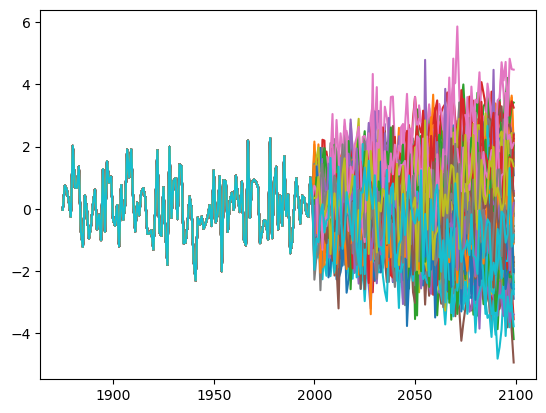

In [13]:
# combine before 2000 data with synthetic annual data
Nobs_2000 = np.where(YrDf_cmip5["years"] == 2000)[0][0] 
add_data = YrDf_cmip5.iloc[:Nobs_2000 ,1].values

# Replicate additional_data across all columns of annual_mean
add_df = pd.DataFrame(np.tile(add_data, (len(annual_mean.columns), 1)).T, columns=annual_mean.columns)

# Concatenate the additional data with the annual_mean data
prep_df = pd.concat([add_df, annual_mean], ignore_index=True)
for i in range(len(prep_df.columns)):
    plt.plot(np.arange(1875, 2100), prep_df.iloc[:,i])

Text(0.5, 1.0, '20-year moving average of precipitation')

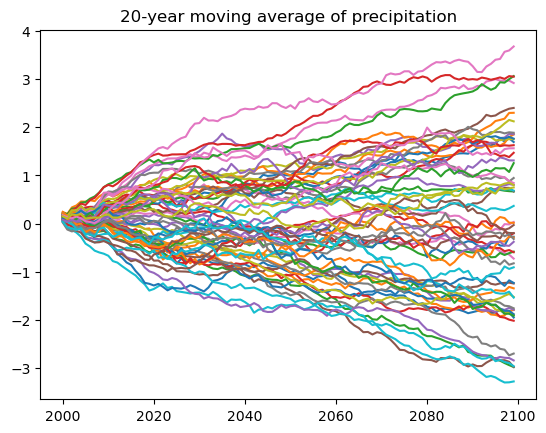

In [18]:
# compute 20 year average
prep_mean = prep_df.rolling(window=20).mean()
# compute 20 year std
prep_std = prep_df.rolling(window=20).std()
# plot 
#for i in range(len(prep_mean.columns)):
    #plt.plot(np.arange(1875, 2100), prep_mean.iloc[:,i])
# take the last 100-year of prep_mean
prep_mean = prep_mean.iloc[-100:,:]
prep_std = prep_std.iloc[-100:,:]
# plot
for i in range(len(prep_mean.columns)):
    plt.plot(np.arange(2000, 2100), prep_mean.iloc[:,i])
plt.title('20-year moving average of precipitation')


Text(0.5, 1.0, '20-year moving std of precipitation')

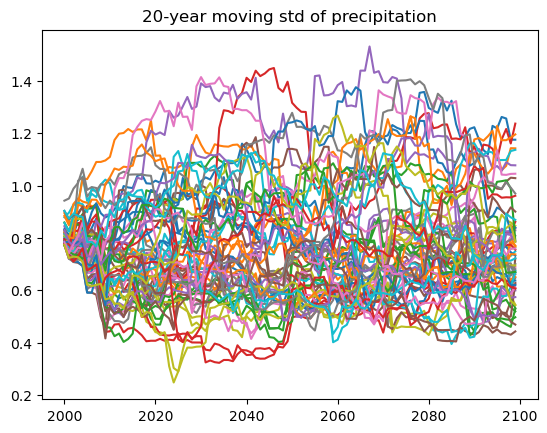

In [19]:
# plt std
for i in range(len(prep_std.columns)):
    plt.plot(np.arange(2000, 2100), prep_std.iloc[:,i])
plt.title('20-year moving std of precipitation')

In [1]:
# normalize to [0,1] for indicators
# Compute the minimum and maximum values across the DataFrame
min_value = prep_mean.iloc[:].min().min()
max_value = prep_mean.iloc[:].quantile(0.8).max()

print(min_value, max_value)
# Normalize the data to the range [0, 1]
min_value = -4
normalized_mean = (prep_mean - min_value) / (max_value - min_value)
for i in range(len(prep_mean.columns)):
    plt.plot(np.arange(2000, 2100),normalized_mean.iloc[:,i])
plt.title('Normalized 20-year moving average of precipitation')

NameError: name 'prep_mean' is not defined

Text(0.5, 1.0, 'Normalized 20-year moving std of precipitation')

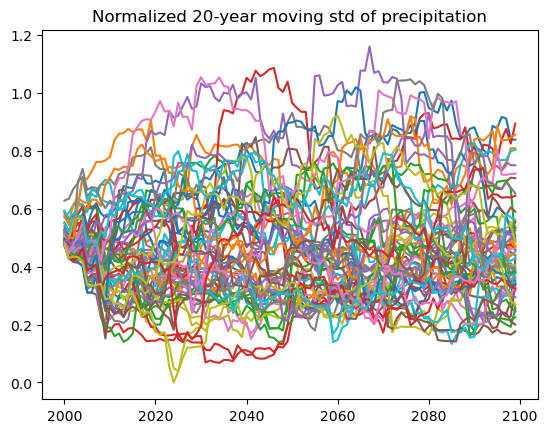

In [23]:
# normalize std
min_value = prep_std.iloc[:].min().min()
max_value = prep_std.iloc[:].quantile(0.8).max()
normalized_std = (prep_std - min_value) / (max_value - min_value)
for i in range(len(prep_std.columns)):
    plt.plot(np.arange(2000, 2100),normalized_std.iloc[:,i])
plt.title('Normalized 20-year moving std of precipitation')


In [25]:
# save the indicators, with index reset to 0
climate_label = 'test'
normalized_mean.reset_index(drop=True, inplace=True)
normalized_std.reset_index(drop=True, inplace=True)
normalized_mean.to_csv(f'data/Annual_GPR/{climate_label}_prep_mean.csv')  # annual indicator
normalized_std.to_csv(f'data/Annual_GPR/{climate_label}_prep_std.csv')


In [ ]:
#compute inflow indicators

In [3]:
result_loc = 'data/Annual_GPR'
select_inflow = 'cmip_runoff.csv'
inflows = pd.read_csv(f'{result_loc}/{select_inflow}', header = None).T/12
inflows

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,9.025578,27.976320,7.744280,16.394776,13.176675,7.147773,8.593810,11.860411,10.754159,7.190449,9.654765,6.650407,10.002475,20.101501,12.131739,16.097654
1,11.191967,26.164979,7.742959,13.151523,9.888390,6.074372,4.380663,5.987795,7.334278,6.226279,7.788014,6.748089,6.732111,18.118622,12.581110,14.675386
2,9.132613,17.973177,7.560629,27.387795,14.442805,6.360329,3.893178,2.711199,4.983417,5.270899,3.504055,6.495966,13.089715,12.869283,5.918153,9.520272
3,11.637539,15.421691,7.070409,35.067086,29.846209,9.650625,7.947523,5.315269,5.416131,9.165747,12.227743,8.827574,25.856318,10.447656,6.395957,6.790961
4,33.054144,12.533340,20.386953,26.683841,19.981800,12.009670,12.183344,9.080213,8.963178,11.109068,11.219249,14.697746,25.069574,8.733062,4.359804,14.116791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2.979362,5.915646,5.537079,2.162644,4.040545,3.548353,7.677279,7.255623,7.458722,6.160673,2.798334,5.987705,6.303252,5.182391,2.370163,6.105840
1196,2.131886,6.902015,3.873282,1.631652,2.499132,3.525839,6.242428,5.675860,7.950857,5.288641,2.474465,3.783522,3.979820,3.078929,1.399985,5.903933
1197,5.796008,11.539201,3.263433,3.003749,3.931829,10.309732,9.697556,11.949430,8.898216,6.087487,6.292172,3.541104,3.599072,4.114732,0.813887,10.759019
1198,13.587259,342.832517,7.296001,14.078020,13.757925,10.864298,13.100956,19.426598,11.886291,6.219803,9.046415,3.866196,10.364742,19.389721,6.157608,17.806806


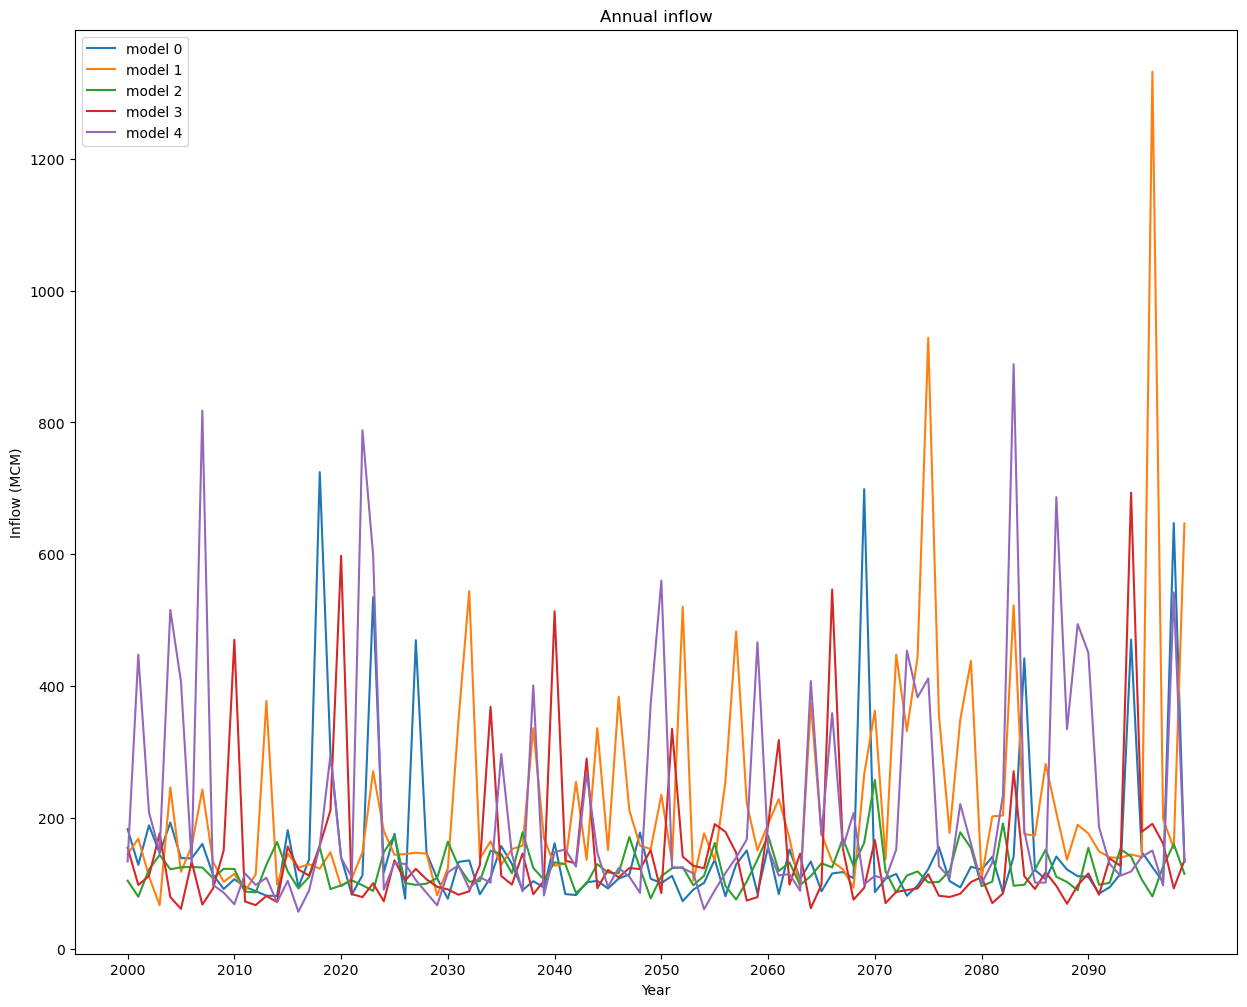

In [10]:
#plot annual inflow
#inflows is a dataframe with 1200 rows and 16 columns. 1200 rows = 100 year*12months, 16 columns = 16 models
#we need to sum every 12 rows to get the annual inflow

plt.figure(figsize = (15, 12))
annual_inflows = inflows.groupby(np.arange(len(inflows))//12).sum()
#plot
for i in np.arange(0,5):
    plt.plot(annual_inflows[i], label = f'model {i}')
plt.legend()
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.title('Annual inflow')
plt.ylabel('Inflow (MCM)')
plt.xlabel('Year')
plt.show()

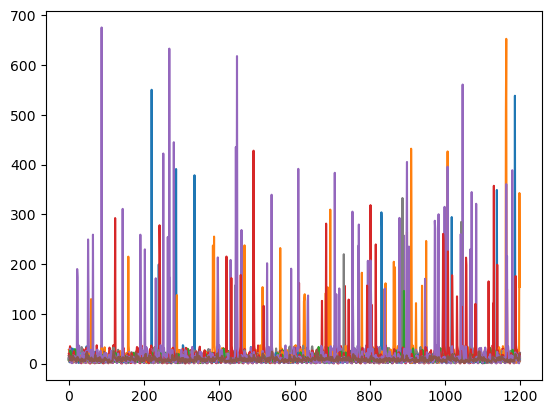

In [6]:

for i in range(16):
    plt.plot(inflows.iloc[:,i])

6.356142315472222 19.38359831574167


Text(0.5, 1.0, 'Normalized inflow indicators')

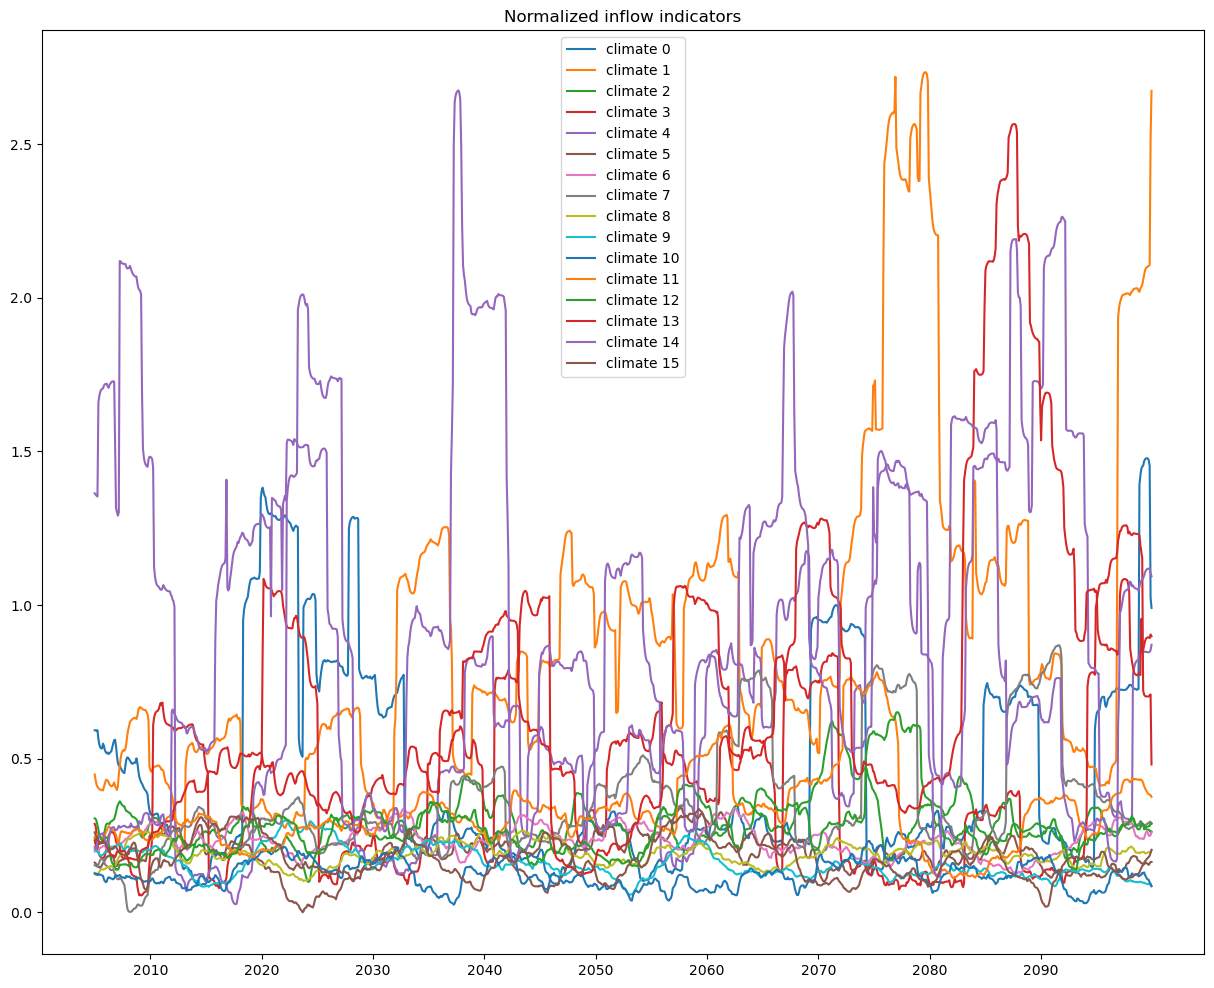

In [5]:
#plot inflow indicators
#compute previous 5 year rolling mean
rolling_means = inflows.rolling(window=60, min_periods=1).mean()
#plt.plot(rolling_means.iloc[:,5])
# Compute the minimum and maximum values across the DataFrame
min_value = rolling_means.iloc[60:].min().min()
max_value = rolling_means.iloc[60:].quantile(0.8).quantile(0.8)

print(min_value, max_value)
# Normalize the data to the range [0, 1]
normalized_inflows = (rolling_means - min_value) / (max_value - min_value)
#set figure size
plt.figure(figsize=(15, 12))
#set x ticks: from 2000-2100, label every 10 years
plt.xticks(np.arange(0, 1200, 120), np.arange(2000, 2100, 10))
#plot
for i in np.arange(0,16):
    plt.plot(normalized_inflows.iloc[60:,i], label = f'climate {i}')
plt.legend()
plt.title('Normalized inflow indicators')

compute bayes indicators

In [55]:
#read in YrDf_cmip5_2300.csv (log, standarized data)
YrDf = pd.read_csv(f'{result_loc}/YrDf_cmip5_2300.csv')
YrDf

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,1875,-0.030201,1.063186,0.819089,-0.258966,-1.294383,-1.322708,-1.682490,0.787112,-0.694233,-0.601572,-1.425760,-1.001183,-1.460050,-1.082570,1.244272,0.076104
1,1876,0.748215,-0.567122,0.200702,-0.684366,-2.473091,-0.728954,1.000202,1.270939,-0.173343,0.045697,0.624418,0.048011,-0.478581,-0.196211,-0.154877,0.310843
2,1877,0.616387,-0.642974,-2.163925,2.119356,0.083858,1.205171,0.122969,-1.145630,0.825325,-1.626903,1.460715,-0.345251,-0.362544,-0.153591,-0.262410,1.795133
3,1878,0.244487,1.179965,0.492212,1.032967,0.082436,-0.562930,-0.958975,-0.203594,0.673849,0.588461,-0.024017,-0.058898,2.128490,-2.932302,-2.470600,-0.624879
4,1879,-0.251457,-1.363517,0.098278,1.405515,-0.093115,-0.440323,-1.174225,1.651659,1.202409,0.146836,-1.418209,-0.205862,-0.955115,0.374352,0.209996,0.722895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2270,0.067186,2.650183,1.100312,1.180426,-0.297521,-0.955549,-1.965426,2.219558,1.605355,-1.918038,-1.185355,0.220237,2.640492,2.244994,-1.326930,0.528663
396,2271,0.094028,2.338841,1.196006,-0.595557,0.552326,-0.741119,-0.166073,2.106040,1.658301,-0.442020,-1.539291,0.434525,-0.006189,1.875816,0.096594,-1.217773
397,2272,0.254336,2.809251,0.299393,0.445996,0.338341,-0.260635,2.213026,0.436409,0.133691,-0.356900,-0.831857,-0.960644,1.857656,2.650134,0.788353,-1.617693
398,2273,-0.349718,-0.030402,1.430127,0.764233,0.794747,0.717766,0.385129,-0.323224,1.269594,0.717672,-0.790535,0.257693,1.304048,2.450325,-0.596567,-0.207683


In [69]:
smoothed_50yrDf = pd.read_csv(f'{result_loc}/smoothed_50yrDf_cmip5_2300.csv')
YrDf_anom = pd.read_csv(f'{result_loc}/YrDf_anom_cmip5_2300.csv')
Nobs = np.where(YrDf['years'] == 2000)[0][0]
YrDf_anom.iloc[:Nobs,1].var()

0.8710238081707218

In [72]:
# GPR sequential learning using GCM virtual obs
def GPR_update(GCM_data, obs, Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3, sigma_n, with_noise=True):

    Nyears = 400  # length of the whole study period (1875-2275)
    # Init null matrix with zeros for records of post_mu, post_std in each update, for each synthetic realization
    mu_mat = np.zeros((Nyears, Ncycles))
    std_mat = np.zeros((Nyears, Ncycles))

    updated_obs = np.copy(obs[:Nobs])

    for i in range(Ncycles):
        #print(f'Cycle {i+1} of {Ncycles}')
    
        updated_Nobs = Nobs + Nyears_per_cycle * i
        updated_obs = obs[:updated_Nobs]
        # GPR update
        prior_mu, prior_cov, post_mu, post_cov, lml = ut.GPR_func(updated_obs, updated_Nobs, GCM_data, sigma1, sigma2,
                                                                sigma3, sigma_n, use_cholesky=True)
        mu_mat[:, i] = post_mu
        if with_noise:
            std_mat[:, i] = np.sqrt(np.diag(post_cov) + sigma_n)
        else:
            std_mat[:, i] = np.sqrt(np.diag(post_cov))

    return mu_mat, std_mat

In [73]:

def compute_mu_std(YrDf, smoothed_50yrDf_cmip5,  Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3, with_noise):


    # init result matrix
    n_models = YrDf.shape[1] - 1 # number of model, first col is years
    mu_gcm = np.zeros((n_models, 400, Ncycles))
    std_gcm = np.zeros((n_models, 400, Ncycles))

    for i in range(n_models):
        #print(f'model {i+1} of {n_models}')

        obs = YrDf.iloc[:,(i+1)].values
        column_indices = [j for j in range(smoothed_50yrDf_cmip5.shape[1]) if j != 0 and j != (i+1)]
        GCM_data = pd.DataFrame(smoothed_50yrDf_cmip5.iloc[:, column_indices])
        
        stdObs = YrDf_anom.iloc[:Nobs,(i+1)].var()
        print('stdObs', stdObs)

        mu_mat, std_mat = GPR_update(GCM_data, obs, Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3,stdObs, with_noise)
        mu_gcm[i] = mu_mat
        std_gcm[i] = std_mat
        

    return mu_gcm, std_gcm

In [78]:
Nyears_per_cycle = 2
Ncycles = int(100/Nyears_per_cycle)


sigma1, sigma2, sigma3 = 0.25, 0.95, 0  # Hyperparameters for annual data
Nobs = np.where(YrDf["years"] == 2000)[0][0] 

mu_test, std_test = compute_mu_std(YrDf, smoothed_50yrDf,  Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3,  with_noise=False)

mu_test.shape

stdObs 0.8710238081707218
stdObs 1.0123071531526704
stdObs 0.9727875829810972
stdObs 0.8609029119339656
stdObs 0.9759650102613082
stdObs 1.06573409521316
stdObs 1.3022441294585108
stdObs 1.0207242915163648
stdObs 1.2318313377065326
stdObs 1.0506026094016438
stdObs 1.0610112814384007
stdObs 0.9915320481758861
stdObs 1.0731974607536245
stdObs 0.9621018698389724
stdObs 1.0449897054762551
stdObs 0.9370510243882892


(16, 400, 50)

In [94]:
result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization/data/Annual_GPR'
file_name = f'cmip_bayes_indicators.npz'
np.savez(f'{result_loc}/{file_name}', mu=mu_test, std=std_test)

In [113]:
def extract_climate_indicators(cliamte_means, cliamte_stds, t, Nyears_per_cycle, normalized = True):

        # input. cliamte_means is i slice of loaded_mu, 2d matrix for ith simulation
        # input. t: simulation time step in months.
        # output: climate indicators: mean(t), mean(t+50), std(t+50), mean(2100), std(2100)

        # get the year index
        T = int(t/12)
        #which update cycle
        cycle_index = int(T/ Nyears_per_cycle)    

        #convert year index in cliamte_means file (climate_means file year start from 1875)
     
        T_convert = T + 125
        mean_t = climate_mean_avg(cliamte_means, 0 ,T_convert, cycle_index)
        std_t = cliamte_stds[T_convert, cycle_index]
        mean_t_50 =climate_mean_avg(cliamte_means, 50, T_convert, cycle_index)
        std_t_50 = cliamte_stds[T_convert + 50, cycle_index]

        #### indicators at year 2100
        years = np.arange(1875, 2275)
        year2100 =np.where(years ==2100)[0][0]
        mean_2100 = climate_mean_avg(cliamte_means, 0 , year2100, cycle_index)
        std_2100 = cliamte_stds[year2100, cycle_index]

        #normalize
          #normalized
        norm_mean_t = normalize_climate_indicators(mean_t, mean = True)
        norm_std_t = normalize_climate_indicators(std_t, mean = False)
        norm_mean_t_50 = normalize_climate_indicators(mean_t_50, mean = True)
        norm_std_t_50 = normalize_climate_indicators(std_t_50 , mean = False)
        norm_mean_2100 = normalize_climate_indicators(mean_2100, mean = True)
        norm_std_2100 = normalize_climate_indicators(std_2100, mean= False)

        if normalized ==True:
            return [norm_mean_t, norm_std_t,norm_mean_t_50, norm_std_t_50,norm_mean_2100, norm_std_2100]  
        else:
            return [mean_t, std_t, mean_t_50, std_t_50, mean_2100, std_2100] 

def climate_mean_avg(climate_means, t_plus,T_convert, cycle_index ):

    T = T_convert + t_plus
    means = [climate_means[T, cycle_index]]
    
    if T_convert - 4 >=0:
        means.append(climate_means[T - 1, cycle_index])
        means.append(climate_means[T - 2, cycle_index])
        means.append(climate_means[T- 3, cycle_index])
        means.append(climate_means[T - 4, cycle_index])
    mean_avg = np.mean(means)

    return mean_avg

def normalize_climate_indicators(indicator, mean = True ):

    if mean == True:
  

        min_value = - 1.8
        max_value = 1.9
    
    else:
      
        
        min_value = 0.3
        max_value = 0.6

    normalized_indicator = (indicator - min_value) / (max_value - min_value)
    return normalized_indicator

In [114]:
num_models = YrDf.shape[1] - 1  # Number of models
num_years = 100  # Number of years for which data is generated

# Pre-allocate numpy arrays for each set of indicators
mean_ts = np.zeros((num_years, num_models))
std_ts = np.zeros((num_years, num_models))
mean_t50s = np.zeros((num_years, num_models))
std_t50s = np.zeros((num_years, num_models))
mean_t2100 = np.zeros((num_years, num_models))
std_t2100 = np.zeros((num_years, num_models))


for model_idx in range(num_models):
    for year_idx in range(num_years):
        t = year_idx * 12  # Assumes t is indexed by month, and you pick the first month of each year
        # Extract indicators
        indicators = extract_climate_indicators(mu_test[model_idx,...], std_test[model_idx,...], t, Nyears_per_cycle,normalized=True)
        mean_ts[year_idx, model_idx] = indicators[0]
        std_ts[year_idx, model_idx] = indicators[1]
        mean_t50s[year_idx, model_idx] = indicators[2]
        std_t50s[year_idx, model_idx] = indicators[3]
        mean_t2100[year_idx, model_idx] = indicators[4]
        std_t2100[year_idx, model_idx] = indicators[5] 

0.31338866651397235 0.6064653668171653


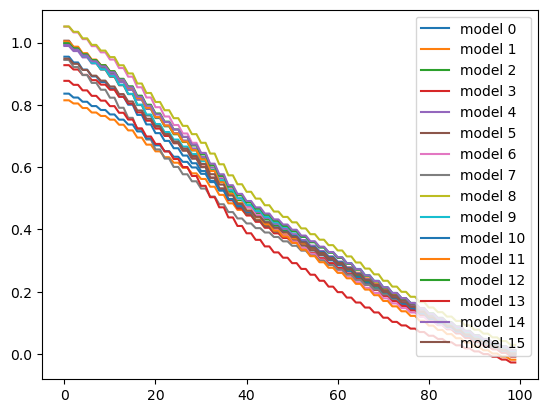

In [93]:
min_value = np.quantile(std_t2100, 0.01)
max_value = np.quantile(std_t2100, 0.99)

print(min_value, max_value)
# Normalize the data to the range [0, 1]
#normalized_means = (mean_ts - min_value) / (max_value - min_value)
#normalized_mean50 = (mean_t50s - min_value) / (max_value - min_value)
normalized_stds = (std_t2100 - min_value) / (max_value - min_value)


for i in np.arange(16):
    plt.plot(normalized_stds[:,i], label = f'model {i}')
plt.legend()

Text(0.5, 1.0, 'Bayes posteior mean at t')

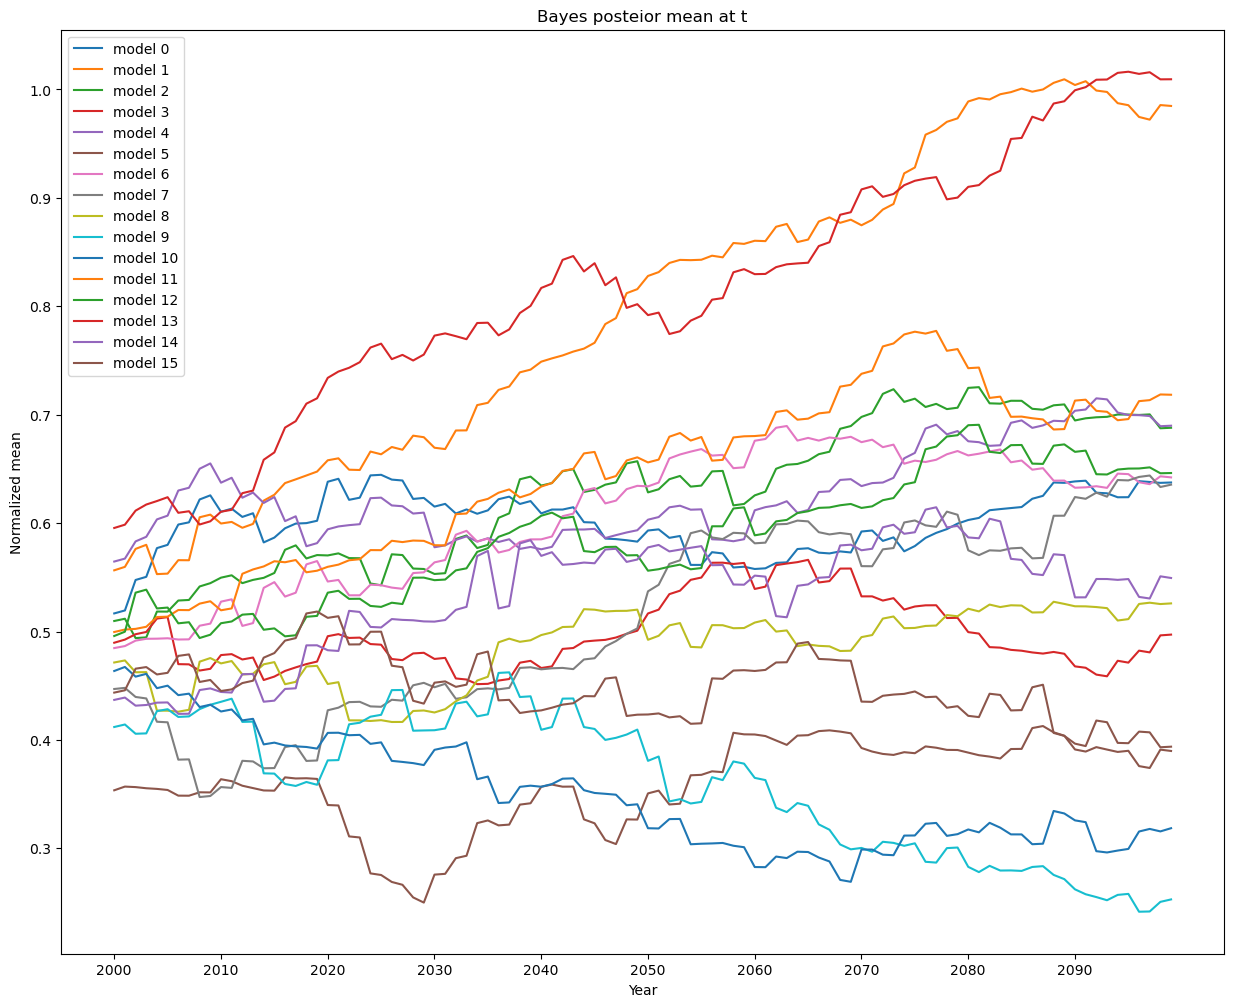

In [116]:
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(mean_ts[:,i], label = f'model {i}')

plt.legend()
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.xlabel('Year')
plt.ylabel('Normalized mean')
plt.title('Bayes posteior mean at t')



Text(0.5, 1.0, 'Annual log standarized precpitation change')

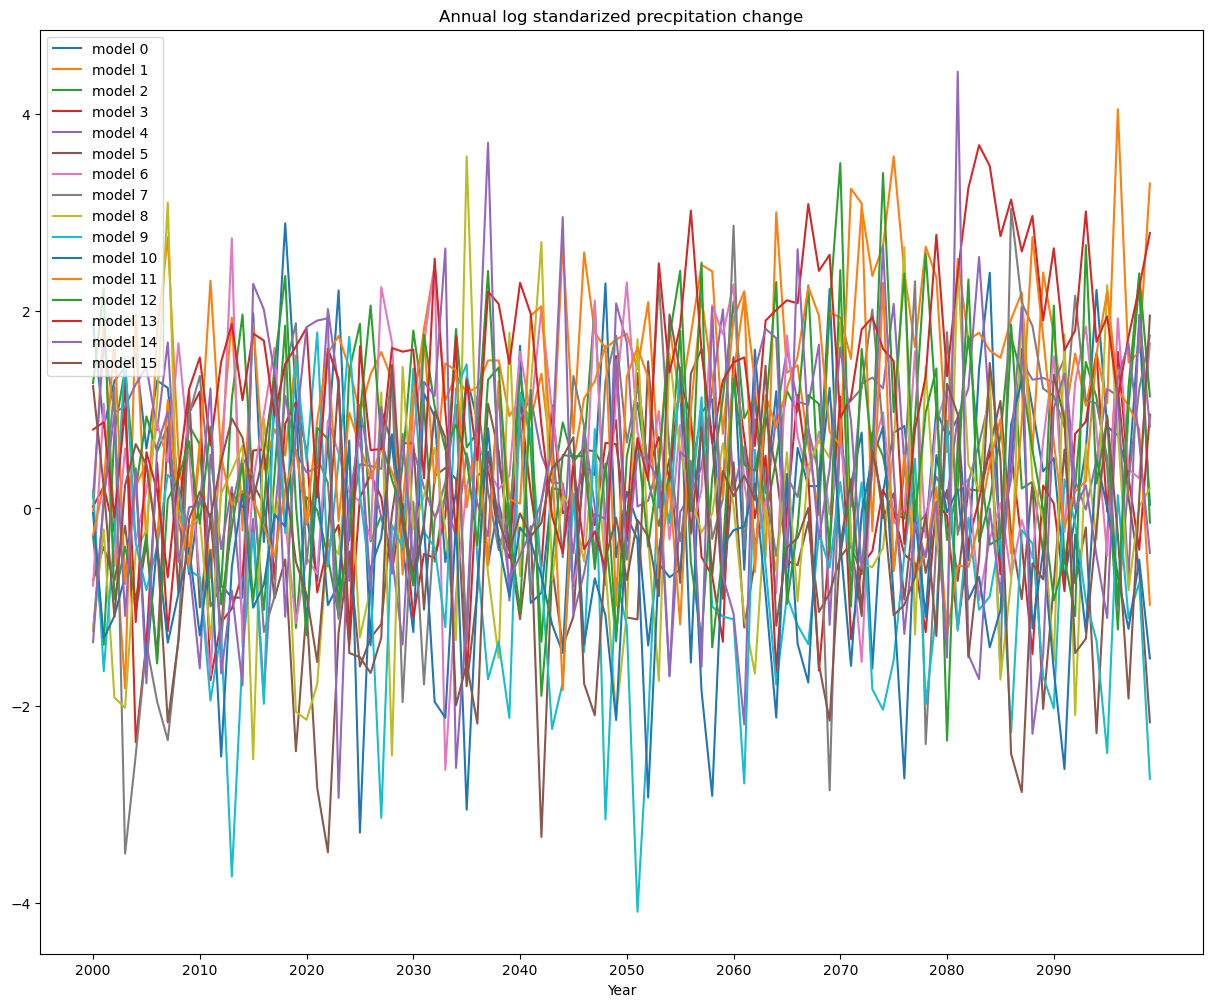

In [110]:
# plot 2000-2100 YrDf data


#read in YrDf_cmip5_2300.csv (log, standarized data)
YrDf = pd.read_csv(f'{result_loc}/YrDf_cmip5_2300.csv')
YrDf
#(slice year 2000 - 2099)
start_year = 2000
end_year = 2099
YrDf = YrDf[(YrDf['years'] >= start_year) & (YrDf['years'] <= end_year)]
YrDf = YrDf.reset_index(drop=True)
# plot YrDf, x axis is year 2000-2099
# set figure size
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf.iloc[:,i+1], label = f'model {i}')
plt.legend()
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.xlabel('Year')
plt.title('Annual log standarized precpitation change')




Bias correct cmip5 model output using cru dataset

Text(0, 0.5, 'Precipitation (mm)')

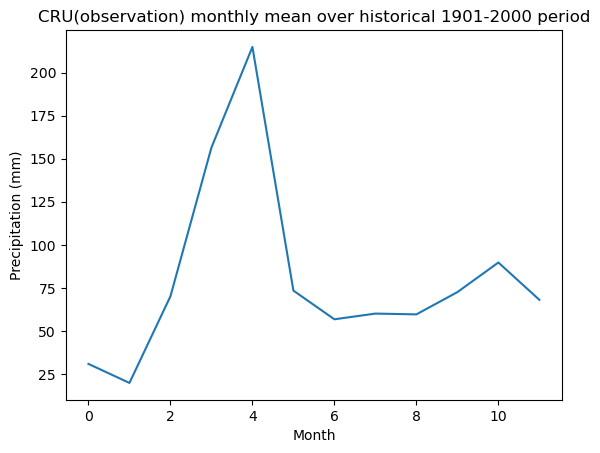

In [19]:
#read cru data
cru_data = pd.read_csv(f'{result_loc}/cru_mat.csv',header = None)
cru_data
# cru_data has 120 rows (1901 - 2020) and 12 cols. each col is a month
# compute the 1901 - 2000, 100 year annual sum of cru data (sum over 12 months)
#cru_annual = cru_data.sum(axis  =1)[:100]
#cru_annual.plot()
# compute monthly mean of cru data
cru_monthly_mean = cru_data.iloc[:100,:].mean(axis = 0)
plt.plot(cru_monthly_mean)
plt.title('CRU(observation) monthly mean over historical 1901-2000 period')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')

Text(0, 0.5, 'Precipitation (mm)')

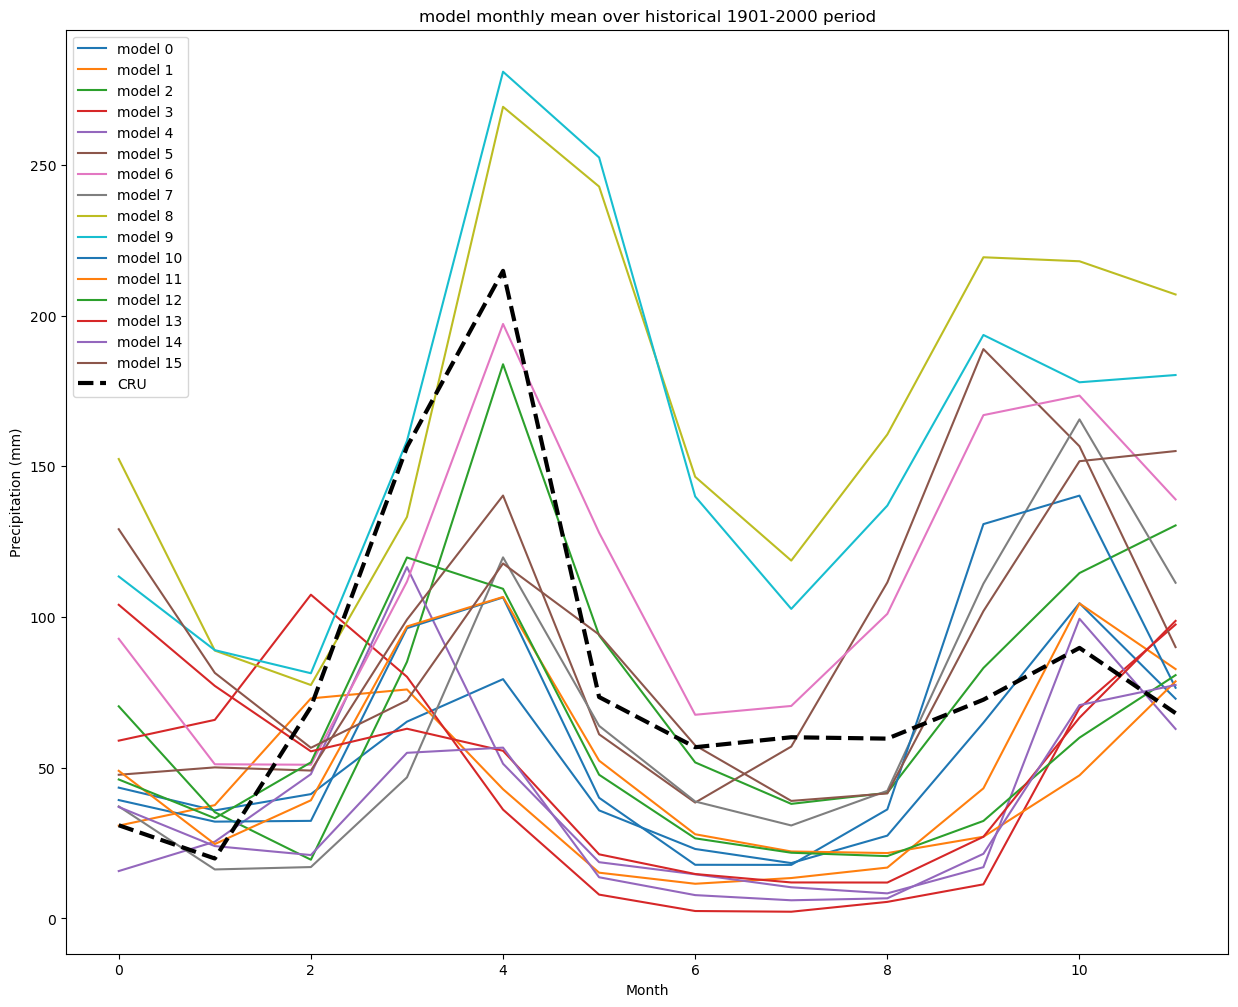

In [30]:
# read Mombas monthly data
#read and process monthly data
file_monthly = 'Mombas_6x6_monthly_precip.txt'   # use as virtual monthly observations
monthly_df = pd.read_csv(f'{result_loc}/{file_monthly}')
year = np.repeat(np.arange(1850, 2301), 12)
monthly_df['year']= year
# filter, only keep 1860 - 2275
monthly_df= monthly_df[(monthly_df['year'] >= 1860) & (monthly_df['year'] <= 2274)].reset_index(drop=True)
monthly_df

#historical monthly data : year 1901 - 2000
#filter out his_df for yead 1901 - 2000
his_df = monthly_df[(monthly_df['year'] >= 1901) & (monthly_df['year'] <= 2000)].reset_index(drop=True)


#compute monthly mean
#add a monthly column, '0 -11' repeat 1-11 100 times

his_df['month'] = np.tile(np.arange(0,12), 100)
# compute monthlly mean
his_monthly_mean = his_df.groupby('month').mean()
his_monthly_mean
#plot, label each model
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(his_monthly_mean.iloc[:,(i+1)], label = f'model {i}')
#plot cru monthly
plt.plot(cru_monthly_mean, label = 'CRU', color = 'black', linestyle = '--', linewidth = 3)
plt.legend()
plt.title('model monthly mean over historical 1901-2000 period')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')



Text(0, 0.5, 'Precipitation (mm)')

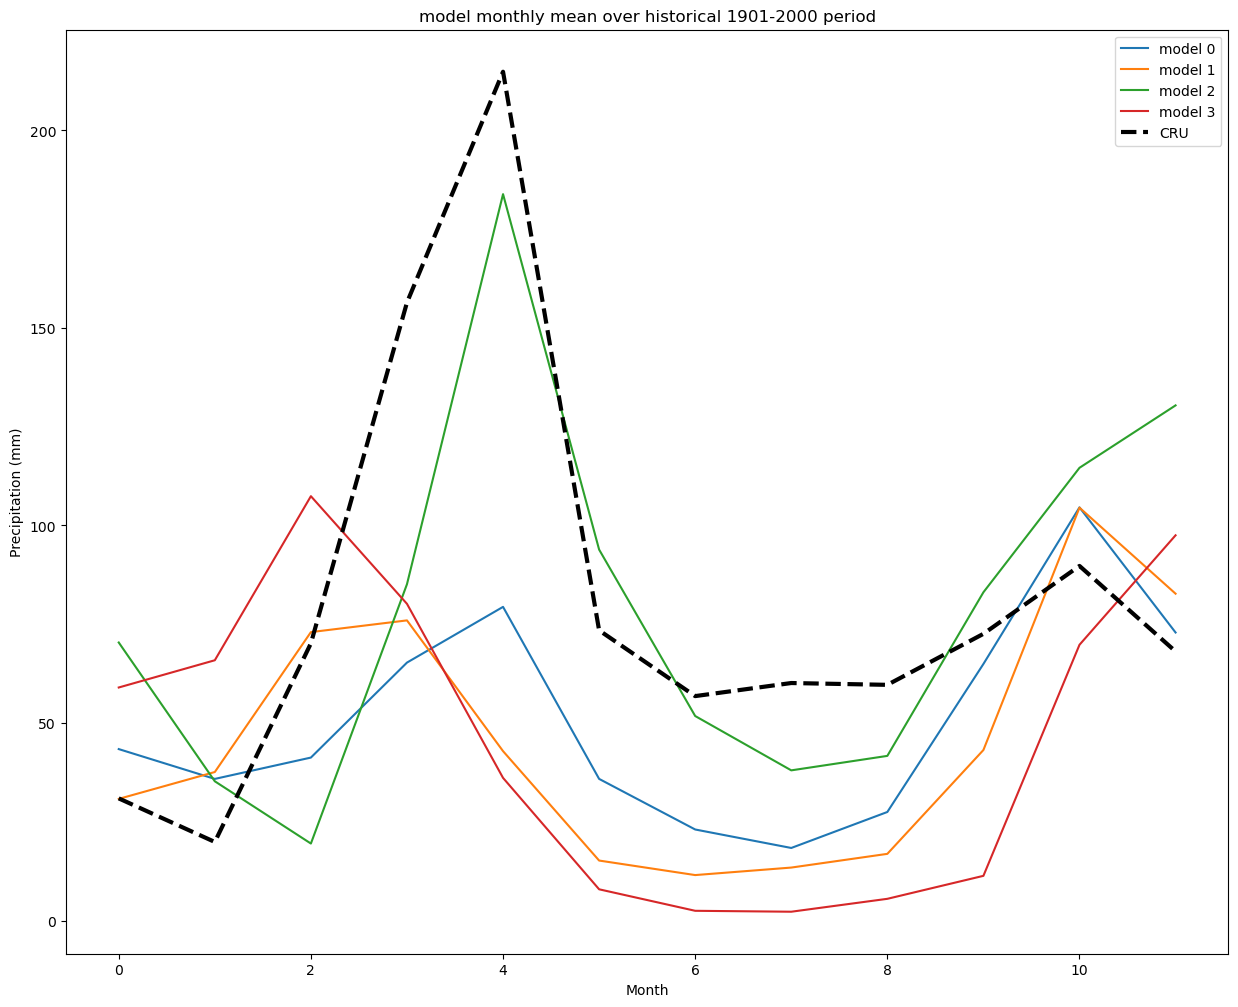

In [36]:
plt.figure(figsize=(15, 12))
for i in range(4):
    plt.plot(his_monthly_mean.iloc[:,(i+1)], label = f'model {i}')
#plot cru monthly
plt.plot(cru_monthly_mean, label = 'CRU', color = 'black', linestyle = '--', linewidth = 3)
plt.legend()
plt.title('model monthly mean over historical 1901-2000 period')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')

In [31]:
his_monthly_mean

,year,bcc_csm1_1,CanESM2,CESM1_CAM5,CSIRO_mk3L_1_2,CSIRO_MK3_6_0,CNRM_CM5,FGOALS_g2,GFDL_CM3,GISS_E2_H,GISS_E2_R,HadGEM2_ES,IPSL_CM5A_LR,IPSL_CM5A_MR,MIROC_ESM,MPI_ESM_LR,NorESM1_M
month,,,,,,,,,,,,,,,,,
0,1950.5,43.394722,30.790957,70.381635,58.988922,15.716558,47.669644,92.793950,37.176297,152.440284,113.465023,39.273425,48.978488,46.104811,104.061411,36.977098,129.148297
1,1950.5,35.846025,37.592042,35.246786,65.884087,25.458244,50.118783,51.152255,16.254172,88.884199,89.018955,32.116693,24.676836,33.265828,77.156409,24.004480,81.476009
2,1950.5,41.248856,73.008611,19.483609,107.419190,47.868856,49.065807,50.997151,17.045173,77.446207,81.351945,32.374898,39.197030,51.780365,55.443864,21.033565,56.617776
3,1950.5,65.292271,75.976737,85.134019,80.171310,116.563532,99.151276,111.761944,46.805136,133.217600,158.428278,96.310946,96.874824,119.765843,62.941960,54.951266,72.311890
4,1950.5,79.399016,42.877617,183.880339,36.105610,51.330322,140.318967,197.246635,119.806652,269.299481,280.945158,106.517603,106.667183,109.372738,55.625252,56.672781,117.777873
5,1950.5,35.850917,15.179297,93.902346,7.901605,18.659117,61.094419,127.976467,63.891990,242.837863,252.484134,40.028100,52.351884,47.672884,21.269547,13.659935,94.178824
6,1950.5,23.042569,11.503521,51.767713,2.459456,14.647714,38.446113,67.578850,38.802419,146.540651,140.005335,17.796372,27.928358,26.573520,14.736671,7.736838,57.420263
7,1950.5,18.366019,13.403457,38.012718,2.225885,10.334102,57.025847,70.502474,30.849353,118.734759,102.708711,17.766860,22.217339,21.800324,11.939297,6.022089,38.996477
8,1950.5,27.474064,16.874618,41.675021,5.492530,8.318150,111.491299,101.066485,42.341479,160.587891,136.981884,36.174945,21.686810,20.678903,11.909654,6.677677,41.478572


compute scaling factor by computing : (his_obs - his_model)/his_model.  then bias corrected future model output = future model*(1 + scaling factor). 

compute scaling factor by computing the ratio between long term monthly mean of observed cru data and cmip5 model output over historical period

Text(0, 0.5, 'Scaling factor')

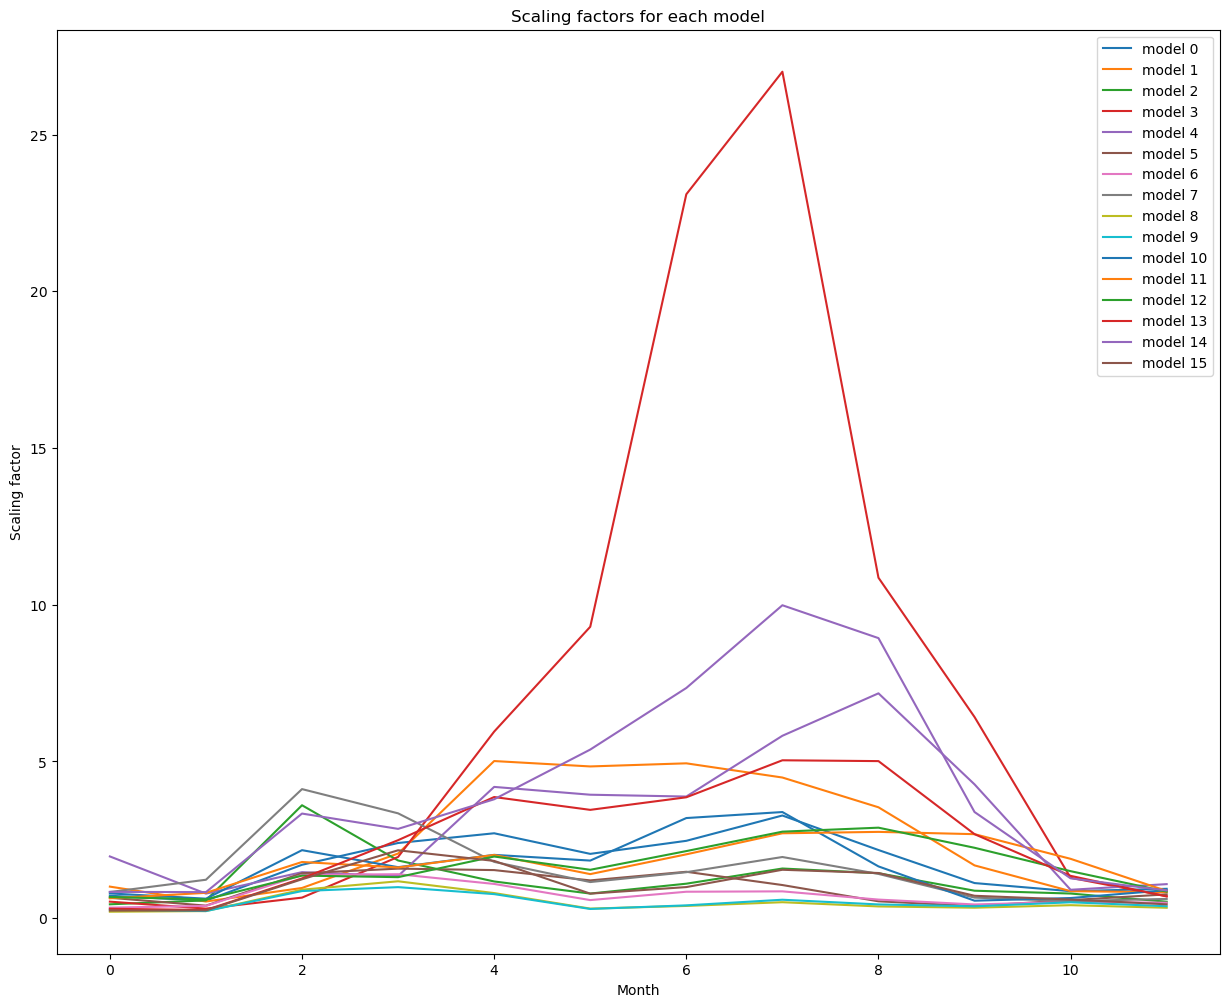

In [38]:
# compute scaling factor for each model
# save scaling factor
scaling_factors = np.zeros((16, 12))
for i in range(16):
    scaling_factors[i] = cru_monthly_mean / his_monthly_mean.iloc[:,(i+1)].values

# plot scaling factors
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(scaling_factors[i], label = f'model {i}')
plt.legend()
plt.title('Scaling factors for each model')
plt.xlabel('Month')
plt.ylabel('Scaling factor')




In [61]:
scaling_factors[0]

array([0.71248297, 0.55470587, 1.70077448, 2.39608761, 2.70621746,
       2.04892947, 2.46543691, 3.27343672, 2.17150262, 1.11746271,
       0.8582712 , 0.93418341])

In [37]:
# compute the future monthly df for year 2000-2099
fut_df = monthly_df[(monthly_df['year'] >= 2000) & (monthly_df['year'] <= 2099)].reset_index(drop=True)
fut_df['month'] = np.tile(np.arange(0,12), 100)
fut_df

,year,bcc_csm1_1,CanESM2,CESM1_CAM5,CSIRO_mk3L_1_2,CSIRO_MK3_6_0,CNRM_CM5,FGOALS_g2,GFDL_CM3,GISS_E2_H,GISS_E2_R,HadGEM2_ES,IPSL_CM5A_LR,IPSL_CM5A_MR,MIROC_ESM,MPI_ESM_LR,NorESM1_M,month
0,2000,41.409094,32.341574,56.077313,64.641986,26.361995,63.874407,71.828247,35.015946,166.813539,156.866763,83.770207,46.533938,59.197886,128.762924,38.343580,116.804693,0
1,2000,76.037815,85.259047,70.421477,51.243178,28.575890,54.944133,17.855376,13.727629,97.199184,103.741094,41.074654,39.036172,27.136359,84.325698,48.321759,137.345811,1
2,2000,38.184580,50.377737,75.012575,177.560900,67.512139,76.583130,46.864321,2.316574,73.691687,103.164560,1.877988,38.502531,107.555795,54.273094,5.719438,63.292322,2
3,2000,74.075137,66.598996,62.573007,132.912869,156.315602,127.564732,142.914532,53.445168,121.127626,253.064716,140.909322,61.686243,186.069905,49.446474,28.352673,47.431026,3
4,2000,232.436373,45.937433,255.127138,31.611404,25.772292,136.308462,191.883512,91.635230,232.405146,195.300150,73.245818,105.494097,84.801652,40.792059,9.574092,197.883245,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2099,9.168109,14.363731,26.575203,1.815588,9.108965,29.433364,33.253850,39.035173,118.449959,82.361817,14.275505,17.690854,30.376185,13.021198,2.036217,45.440715,7
1196,2099,10.482753,43.292180,26.798860,6.718441,6.225276,40.107355,78.441444,38.394052,167.516758,89.901694,17.827050,14.384517,15.704839,8.269502,3.352684,68.249417,8
1197,2099,57.948767,82.476981,27.618349,23.512629,25.723577,175.695980,182.234721,132.450803,195.695338,136.628923,74.313350,21.900212,22.900458,32.080812,1.896821,166.459546,9
1198,2099,124.984201,285.624110,98.849080,116.749922,97.856115,126.717726,207.494298,184.929501,283.108071,123.946958,86.390740,26.424201,100.230335,174.355997,40.874550,234.340773,10


In [59]:
#find the index where max value of first model
max_index = np.argmax(scaled_fut_df.iloc[:,0].values)
max = scaled_fut_df.iloc[max_index,0]
print(max, max_index)
print(fut_df.iloc[max_index,1])


1099.4270988804326 220
406.259702245742


Text(0, 0.5, 'Precipitation (mm)')

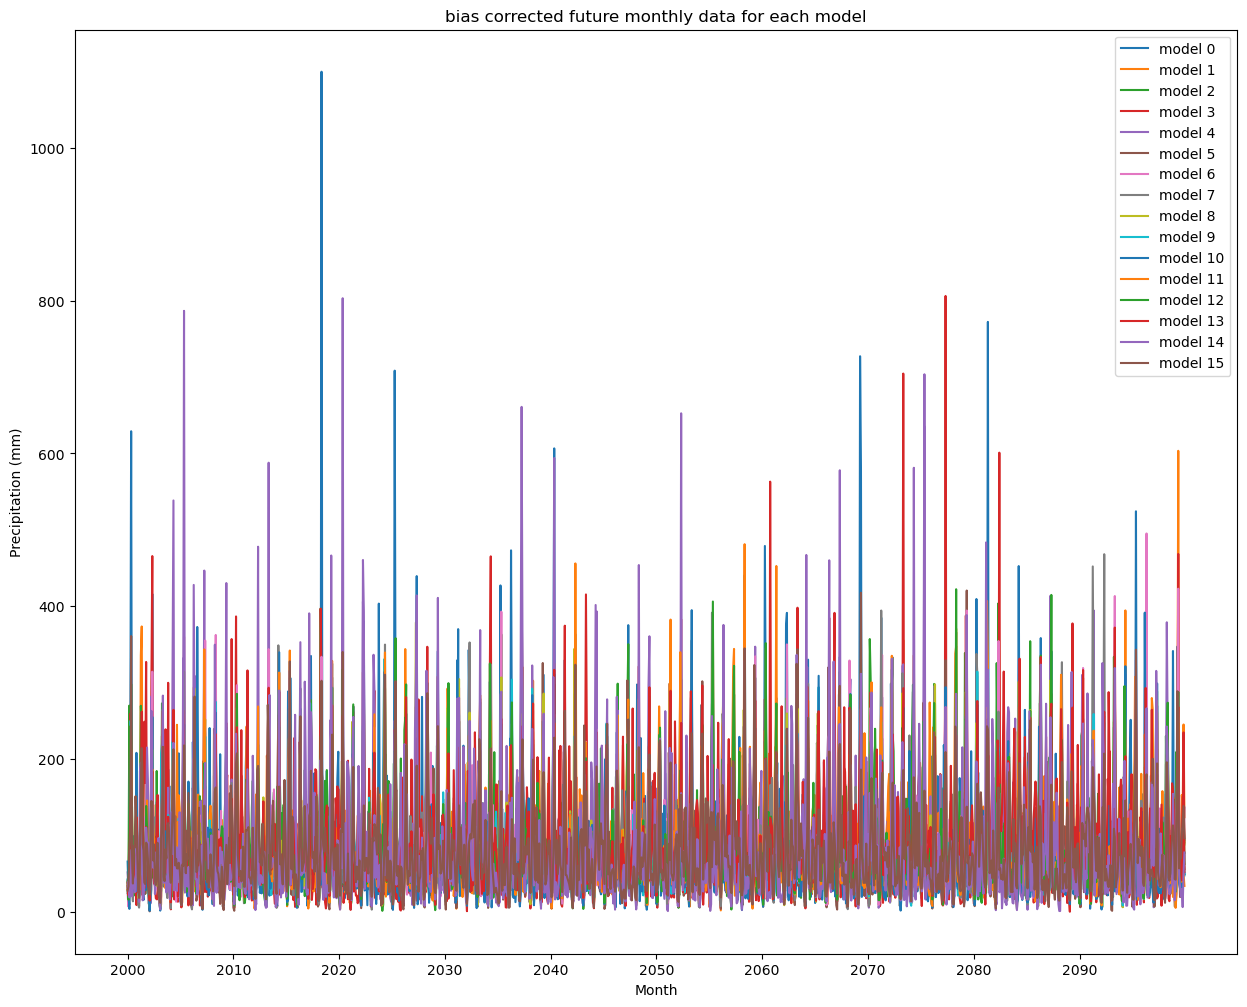

In [66]:
# for each model, scale the future monthly data by the scaling factor
# future monthlt data for each model has 12 *100 values. 12 months, 100 years. scaling factor has 12 values for each model
scaled_fut_df = pd.DataFrame()
# need to repeat scaling_factors 100 times
for i in range(16):
    scaled_fut_df[i] = fut_df.iloc[:,(i+1)] * np.tile(scaling_factors[i], 100)
scaled_fut_df
    

    

#plot scaled future monthly data
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(scaled_fut_df[i], label = f'model {i}')
plt.legend()
plt.title('bias corrected future monthly data for each model')
plt.xlabel('Month')
#xticks label: year 2000-2099
plt.xticks(np.arange(0, 1200, 120), np.arange(2000, 2100, 10))
plt.ylabel('Precipitation (mm)')
#save scaled future monthly data




Text(0, 0.5, 'Precipitation (mm)')

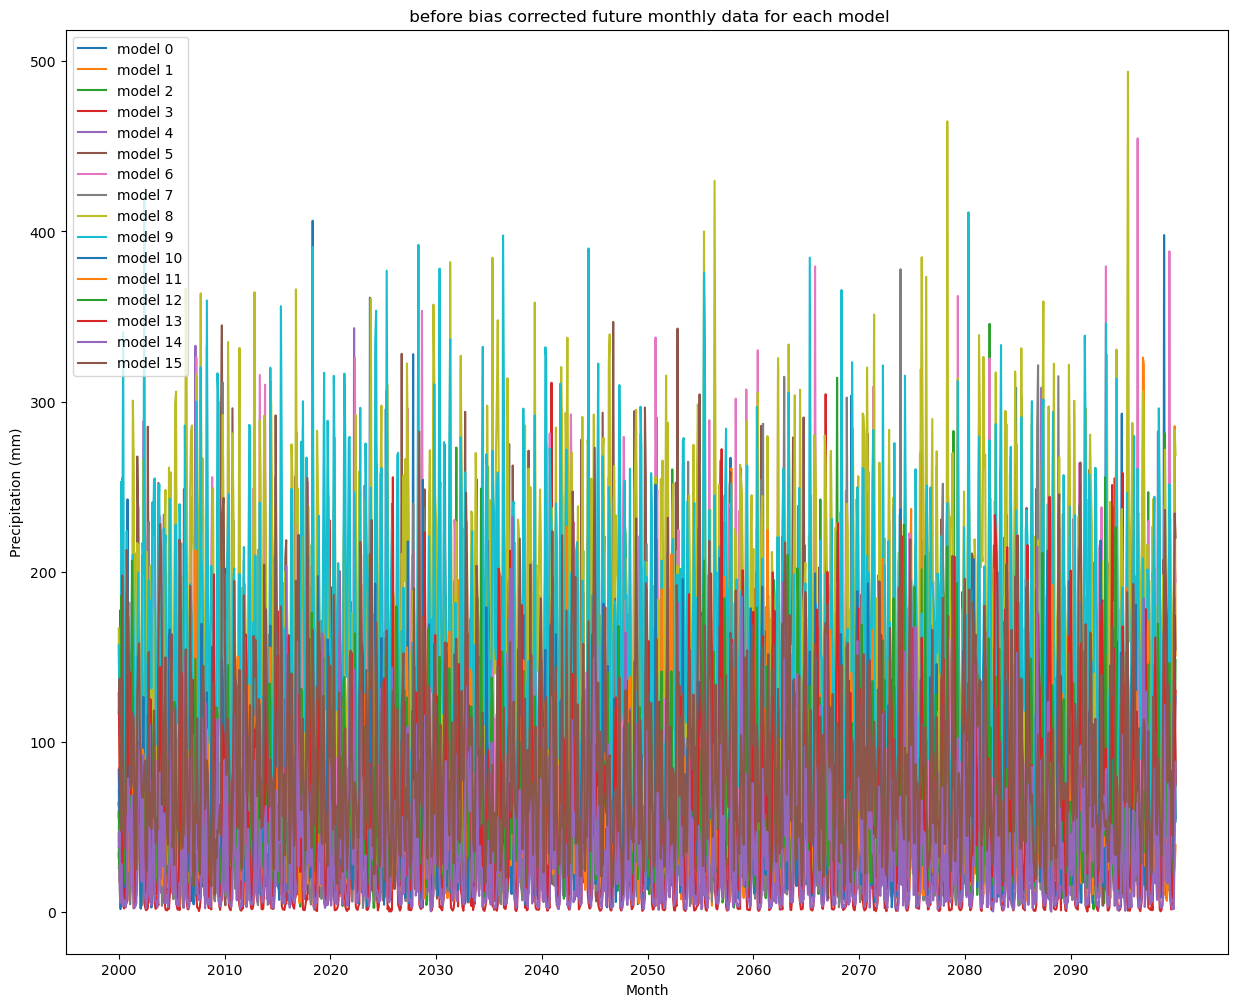

In [68]:
# plot monthly precipitation before scaling
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(fut_df.iloc[:,(i+1)], label = f'model {i}')
plt.legend()
plt.title(' before bias corrected future monthly data for each model')
plt.xlabel('Month')
plt.xticks(np.arange(0, 1200, 120), np.arange(2000, 2100, 10))
plt.ylabel('Precipitation (mm)')

Text(0, 0.5, 'Precipitation (mm)')

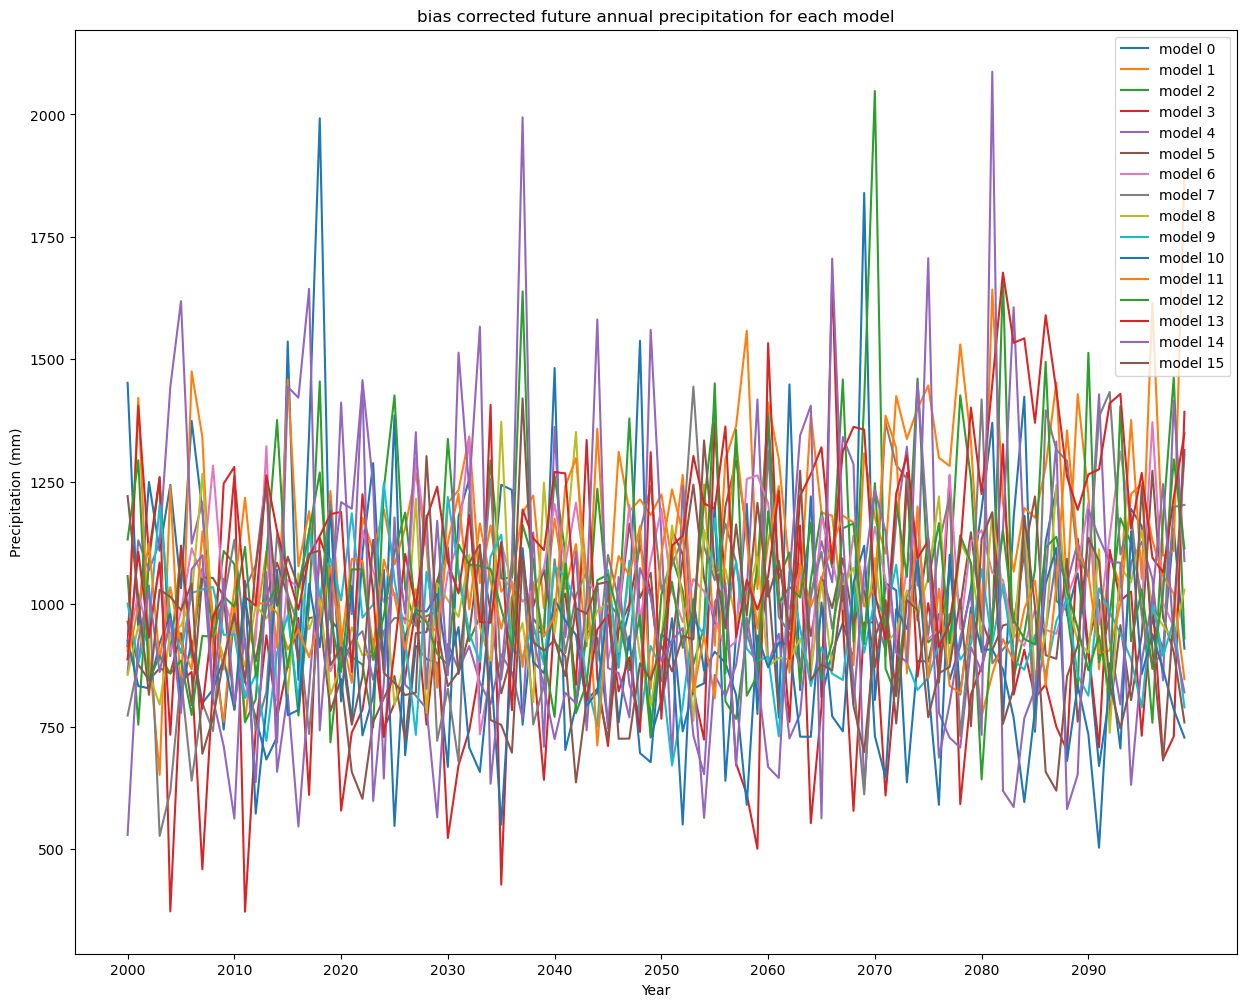

In [65]:
# compute bias corrected annual precipitation
# annual sum of scaled future monthly data, sum over every 12month (scaled future monthly data has 12*100 values each model)
# annual sum for each model

scaled_fut_annual = scaled_fut_df.groupby(np.arange(len(scaled_fut_df))//12).sum()
# plot
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(scaled_fut_annual[i], label = f'model {i}')
plt.legend()
plt.title('bias corrected future annual precipitation for each model')
plt.xlabel('Year')
# xticks is 2000-2100
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.ylabel('Precipitation (mm)')
#save scaled future annual precipitation



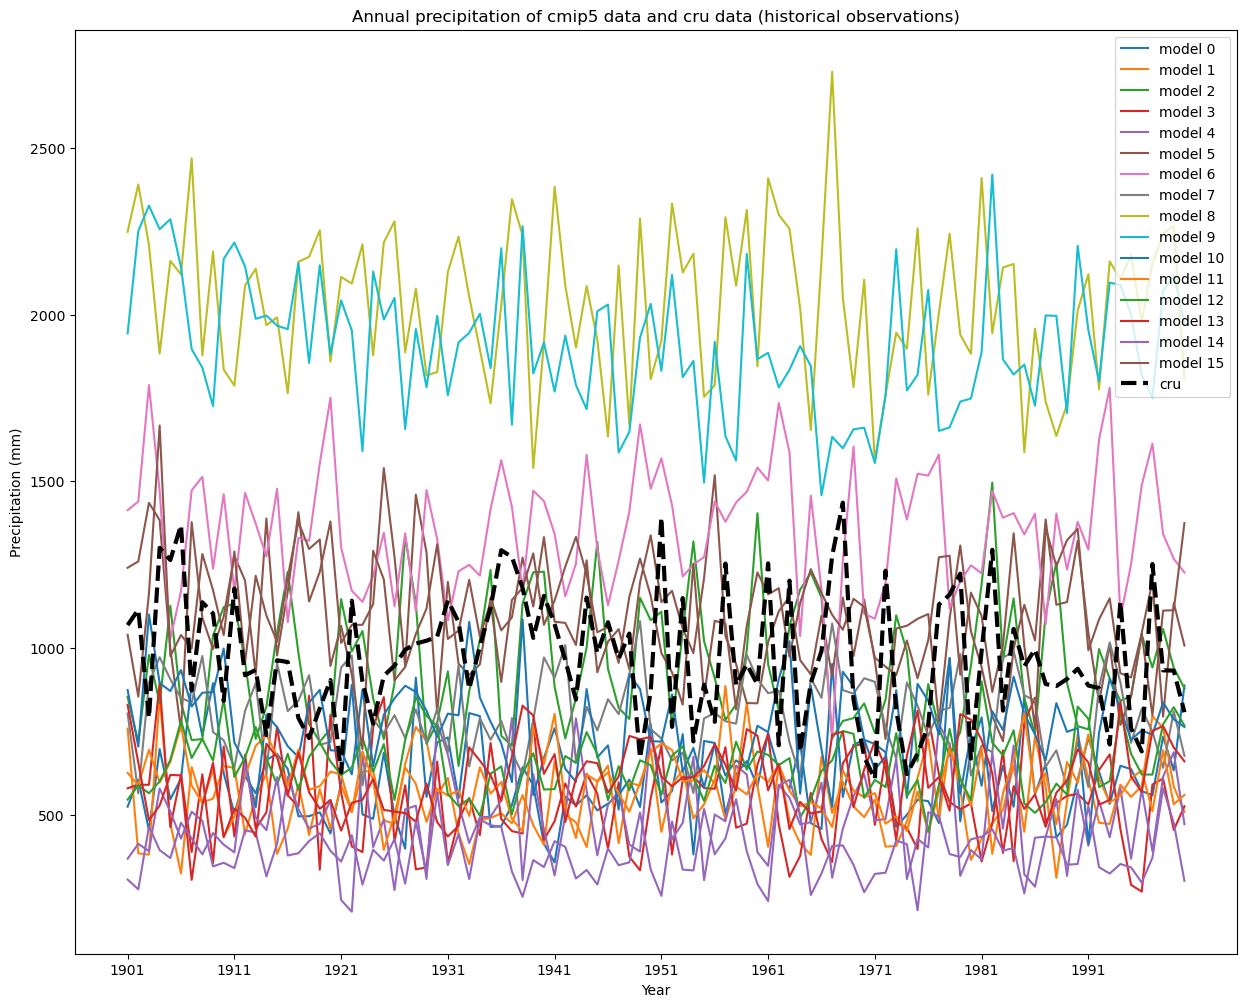

In [140]:
# plot his_annual, label as model 0 - model 15,  and also cru_annual for year 1901 - 2000, label
plt.figure(figsize=(15, 12))

for i in range(16):
    plt.plot(his_annual.iloc[:,i].values, label = f'model {i}')

plt.plot(cru_annual, label = 'cru', color = 'black', linewidth = 3, linestyle = '--')
plt.legend()
plt.xticks(np.arange(0, 100, 10), np.arange(1901, 2001, 10))
plt.xlabel('Year')
plt.title('Annual precipitation of cmip5 data and cru data (historical observations)')
plt.ylabel('Precipitation (mm)')
plt.show()

In [142]:
his_annual.mean(axis = 0)

bcc_csm1_1         612.353426
CanESM2            547.619057
CESM1_CAM5         947.586971
CSIRO_mk3L_1_2     545.273277
CSIRO_MK3_6_0      488.200898
CNRM_CM5          1089.972512
FGOALS_g2         1350.597662
GFDL_CM3           801.012193
GISS_E2_H         2034.457334
GISS_E2_R         1907.189769
HadGEM2_ES         766.031046
IPSL_CM5A_LR       593.817708
IPSL_CM5A_MR       650.061558
MIROC_ESM          607.508876
MPI_ESM_LR         397.409586
NorESM1_M         1098.156243
dtype: float64

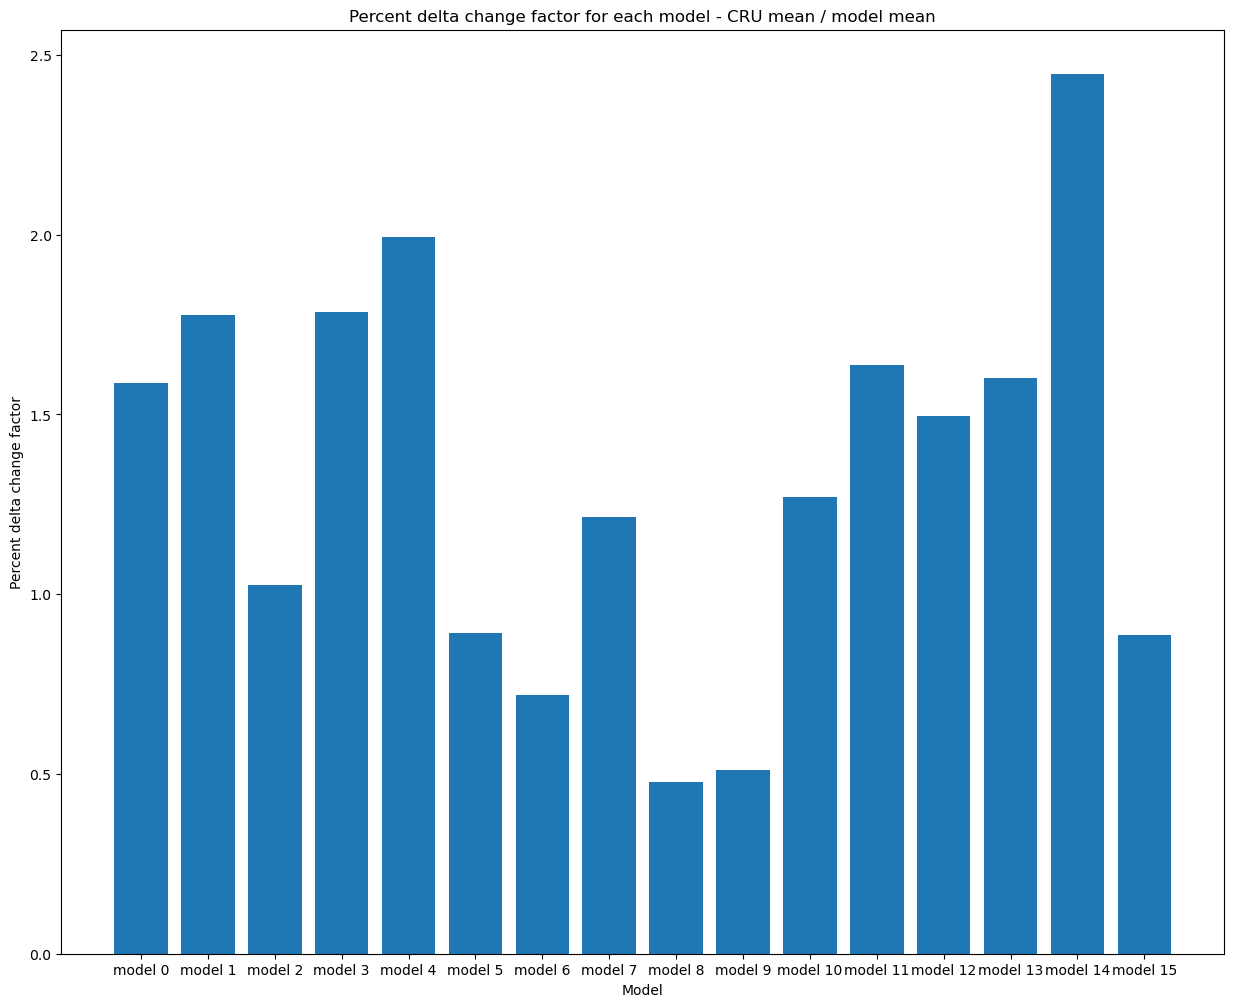

In [147]:
# compute percent delta change factor i
# compute the mean of the 100 year annual mean of his_annual (model 0 - model 15)
his_mean = his_annual.mean(axis = 0)
#compute the mean of the 100 year annual mean of cru_annual
cru_mean = cru_annual.mean()
#compute the percent delta change factor i
delta_change = cru_mean / his_mean
# plot delta_change as bar, x axis is model 0 - model 15
plt.figure(figsize=(15, 12))
plt.bar(np.arange(16), delta_change)
# set x ticks as 'model 0' - 'model 15'
plt.xticks(np.arange(16), [f'model {i}' for i in range(16)])

plt.xlabel('Model')
plt.ylabel('Percent delta change factor')
plt.title('Percent delta change factor for each model - CRU mean / model mean')
plt.show()


In [12]:
preps = pd.read_csv(f'{result_loc}/cmip_month_prep.csv')

preps

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,65.781227,57.450126,57.567385,115.321124,52.527664,57.005889,51.734191,42.524100,79.761094,80.010211,106.377948,76.229847,88.584983,206.180027,93.856144,103.467641
1,120.791358,151.450361,72.292699,91.417687,56.938967,49.035902,12.860309,16.671121,46.475323,52.913356,52.159801,63.947338,40.607427,135.025473,118.280400,121.663323
2,60.658861,89.488761,77.005790,316.768155,134.521496,68.348023,33.753960,2.813296,35.235327,52.619293,2.384815,63.073150,160.948791,86.904115,13.999851,56.065446
3,117.673509,118.303480,64.235681,237.116190,311.467075,113.847491,102.933985,64.904934,57.916593,129.076172,178.937655,101.051686,278.438985,79.175551,69.400733,42.015232
4,369.241348,81.601202,261.906312,56.394658,51.352650,121.650994,138.203823,111.283746,111.123406,99.613238,93.013257,172.815784,126.899005,65.317777,23.435146,175.288441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,14.564179,25.515090,27.281352,3.239005,18.150093,26.268347,23.951037,47.405133,56.636280,42.008812,18.128151,28.980377,45.455573,20.850030,4.984183,40.252181
1196,16.652582,76.902294,27.510952,11.985681,12.404190,35.794546,56.497337,46.626543,80.097334,45.854542,22.638180,23.564081,23.501057,13.241436,8.206589,60.456528
1197,92.055647,146.508422,28.352217,41.946466,51.255582,156.803109,131.254295,160.851035,93.570787,69.687860,94.368892,35.875963,34.268736,51.369000,4.642976,147.452779
1198,198.546098,507.369903,101.475673,208.281538,194.983467,113.091565,149.447469,224.582267,135.366767,63.219398,109.705705,43.286962,149.986816,279.185366,100.051368,207.583157


In [11]:
# apply the delta change factor to each of the model model in preps
# compute the 100 year annual sum of the adjusted model
# plot the adjusted model 
# save the adjusted model as a new csv file

adj_models = pd.DataFrame()
# set figure size
plt.figure(figsize=(15, 12))
for i in range(5):
    adj_model = preps.iloc[:,i] * delta_change[i]
    adj_models[f'model_{i}'] = adj_model
    adj_model_annual = adj_model.groupby(np.arange(len(adj_model))//12).sum()
    plt.plot(adj_model_annual, label = f'model {i}')
plt.legend()
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.title('bias corrected model precipitation ')
plt.show()




NameError: name 'preps' is not defined

<Figure size 1500x1200 with 0 Axes>

In [152]:
# save as cmip_month_prep.csv
adj_models.to_csv(f'{result_loc}/cmip_month_prep.csv', index = False)


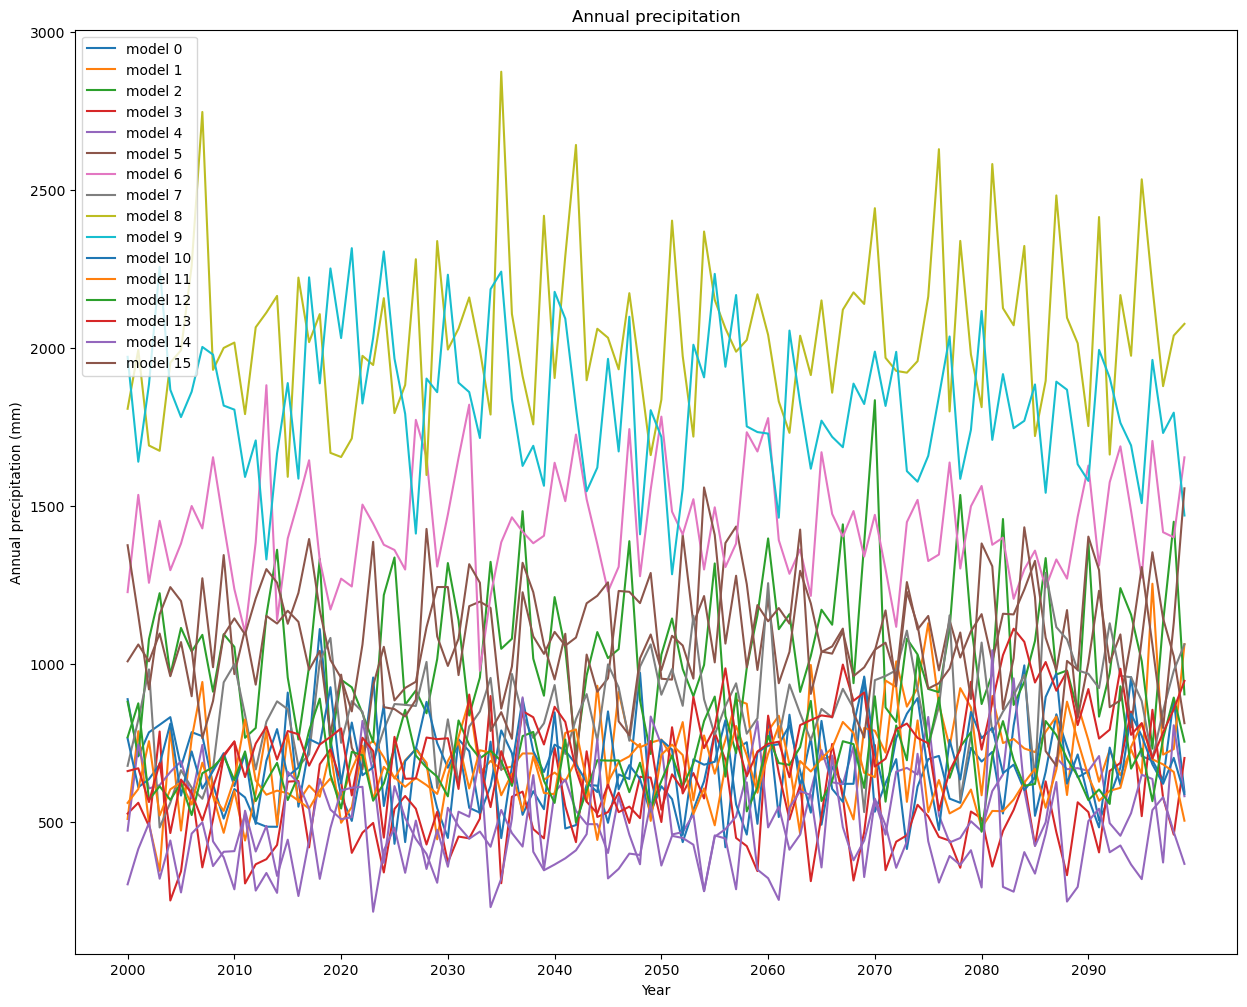

In [103]:

#preps is monthly prep, 1200 rows represent 12months *100 year,  so we need to sum every 12 months up to get annual prep for 100 years
# preps has 1201 rows * 16 cols. the first row is model name.preps has 16 cols, which is 16 models

#set fig size , note that the x axis is year 2000-2099, label every 10 years. 
#sum every 12 rows to get annual preps
annual_preps = preps.groupby(np.arange(len(preps))//12).sum()
annual_preps
# plot
plt.figure(figsize=(15, 12))

for i in range(16):
    plt.plot(annual_preps.iloc[:,i], label = f'model {i}')
plt.xticks(np.arange(0, 100, 10), np.arange(2000, 2100, 10))
plt.legend()
plt.title('Annual precipitation')
plt.ylabel('Annual precipitation (mm)')
plt.xlabel('Year')
plt.show()


